In [1]:
from nilearn import image, plotting
from pathlib import Path
from nilearn.reporting import get_clusters_table
import numpy as np

In [2]:
root_folder = Path('/data/ds-mlearn')


# Get RPE masks

In [3]:
base_dir = root_folder / 'nipype' / 'model2' 
cluster_mapping = {
    0: "Caudate, Putamen R",
    2: "Caudate, Putamen L",
    7: "Angular Gyrus L",
    4: "Visual cortex (Mid, Lat Occipital) L",
    3: "vmPFC",
    8: "Visual Cortex (Lingual, Fusiform) L",
    5: "Cerebellum R"
}

cluster_fn = root_folder / 'nipype' / 'model2' / '2ndLevel' / 'cluster_SnPM_SecondLevel_con1' / 'SnPM_filtered_t8_0_pos.nii'

df, clusters = get_clusters_table(cluster_fn, stat_threshold=4.0, return_label_maps=True)

df = df[df['Cluster Size (mm3)'] != '']
min_cluster_size = 83
df['Cluster size (voxels)'] = np.round(df['Cluster Size (mm3)'].astype(float) / (15.5)).astype(int)
df = df[df['Cluster size (voxels)'] > min_cluster_size]

df[['X', 'Y', 'Z']] = df[['X', 'Y', 'Z']].astype(int)

df.rename(columns={'Cluster ID': 'Cluster Index', 'X':'Max X', 'Y':'Max Y', 'Z':'Max Z',
                   'Peak Stat':'T', 'Cluster size (voxels)': 'Voxels'}, inplace=True)

df = df[['Cluster Index', 'Voxels', 'T', 'Max X', 'Max Y', 'Max Z']]

df['T'] = df['T'].round(2)
df['P_FWE_corr'] = 0.0002 
df.to_csv(base_dir / 'ROI' / 'snpm_stats_con1_8_0_pos.csv')

clusters = clusters[0]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68151/3168833379.py:14: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  df, clusters = get_clusters_table(cluster_fn, stat_threshold=4.0, return_label_maps=True)


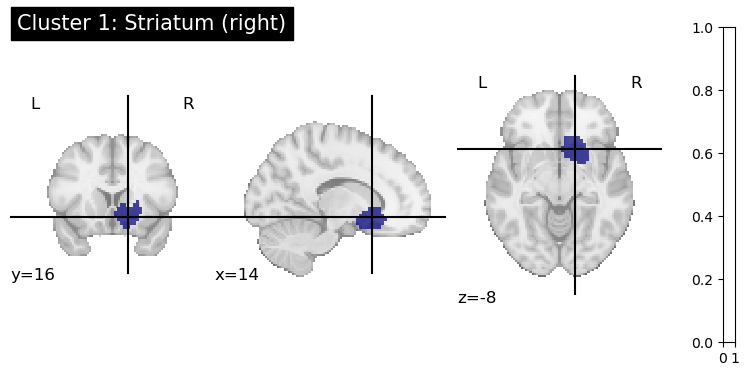

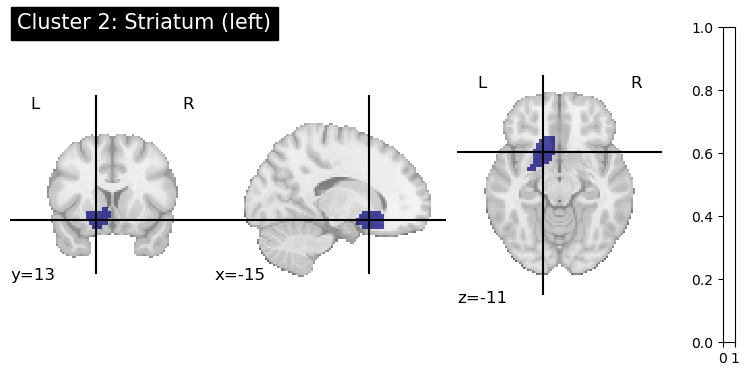

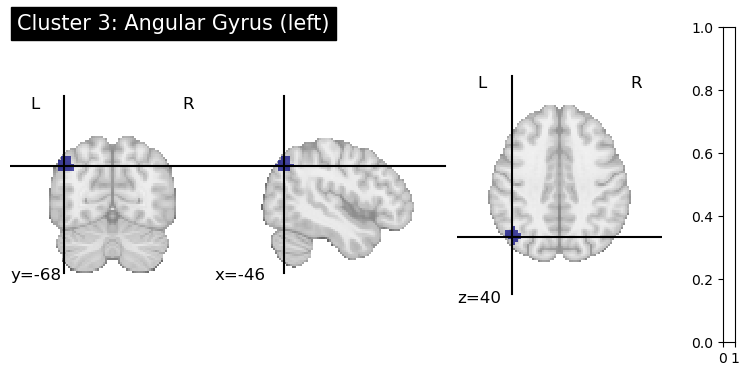

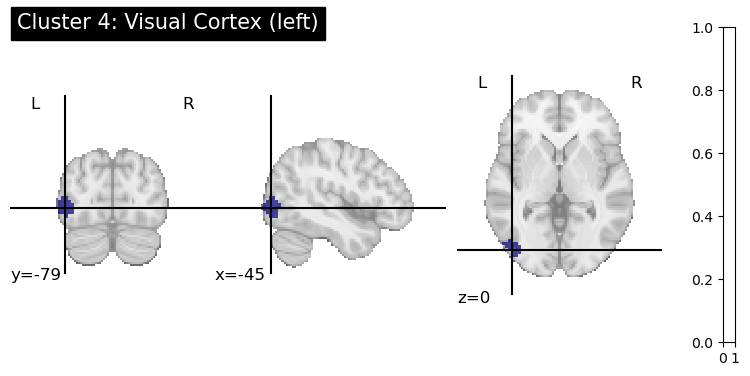

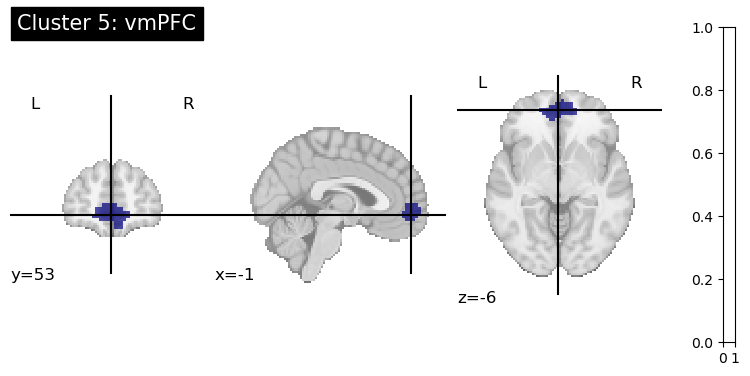

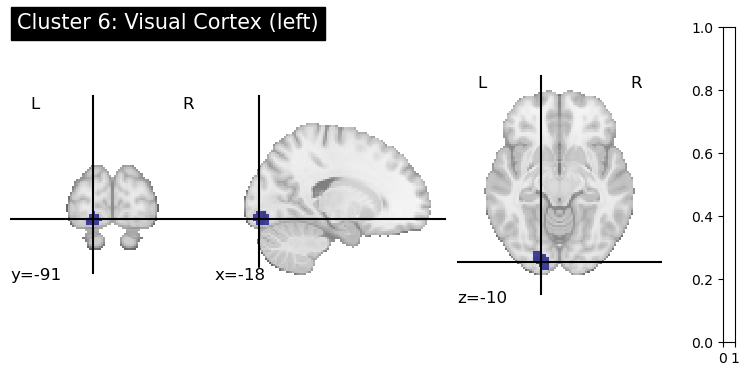

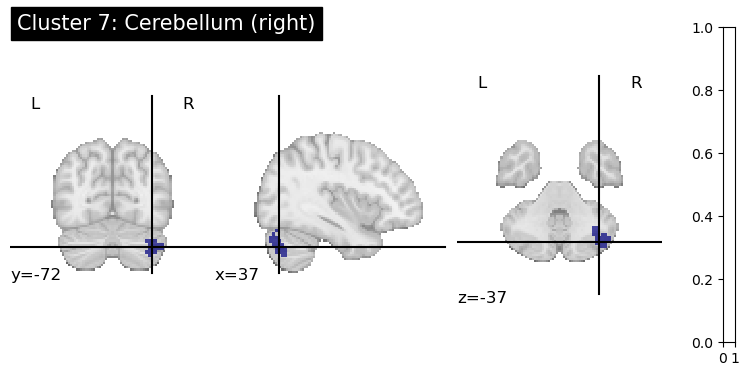

In [20]:
zmaps = []
zmap = image.load_img(cluster_fn)
zmap = image.math_img("np.nan_to_num(zmap)", zmap=zmap)

cluster_labels = ['Striatum (right)', 'Striatum (left)', 'Angular Gyrus (left)', 'Visual Cortex (left)', 'vmPFC', 'Visual Cortex (left)', 'Cerebellum (right)']

for i, cluster in enumerate(df['Cluster Index'].unique()[:len(cluster_labels)]):

    c = image.math_img(f"clusters == {cluster}", clusters=clusters)
    plotting.plot_roi(c, title=f'Cluster {i+1}: {cluster_labels[i]}' )

    target_fn = base_dir / 'ROI' / f'cluster_{cluster}_con1_8_0_pos.nii'

    c.to_filename(target_fn)

    zmap_cluster = image.math_img(f"zmap * (clusters == {cluster}).squeeze()", zmap=zmap, clusters=clusters)
    zmap_cluster.to_filename(target_fn.with_suffix('.zmap.nii.gz'))

    zmaps.append(zmap_cluster)

combined_zmap = image.math_img('im.sum(-1)', im=image.concat_imgs(zmaps))

combined_zmap.to_filename(base_dir / 'ROI' / 'combined_clusters_con1_8_0_pos.zmap.nii.gz')

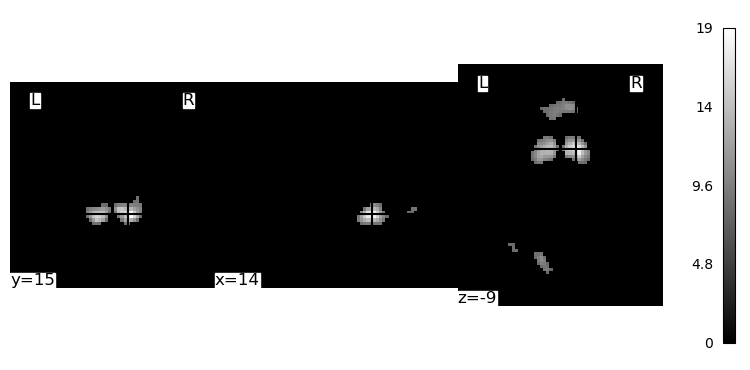

# Extract betas

In [5]:
from nilearn.input_data import NiftiMasker

subjects = range(1,65)
subjects = [str(sub).zfill(2) for sub in subjects if sub not in [8, 13, 16, 31, 32, 44]]

def get_mean_beta(subject, cluster, contrast, model):
    assert model == 'model2', "Only model2 is supported"
    assert contrast in [2, 3]

    fn = root_folder / 'nipype' / model / '1stLevel' / f'sub-{subject}' / f'con_{contrast:04d}.nii'
    mask = root_folder / 'nipype' / model / 'ROI' / f'cluster_{cluster}_con1_8_0_pos.nii'

    masker = NiftiMasker(mask_img=mask, )
    return masker.fit_transform(fn).mean()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68151/3226058246.py:1: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiMasker


In [6]:
from tqdm.contrib.itertools import product

betas = []

for subject, cluster, contrast in product(subjects, range(1, 8), [2, 3]):
    betas.append([subject, cluster, contrast, get_mean_beta(subject, cluster, contrast, 'model2')])
    # try:
    #     betas.append([subject, cluster, contrast, get_mean_beta(subject, cluster, contrast, 'model2')])
    # except FileNotFoundError:
    #     print(f"File not found for subject {subject}, cluster {cluster}, contrast {contrast}")
    #     continue
    # except Exception as e:
    #     print(f"Error for subject {subject}, cluster {cluster}, contrast {contrast}: {e}")
    #     continue
    


/Users/gdehol/mambaforge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 812/812 [03:08<00:00,  4.31it/s]


In [7]:
import pandas as pd
betas = pd.DataFrame(betas, columns=['subject', 'cluster', 'contrast', 'beta'])

In [8]:
cluster_labels = ['Striatum (right)', 'Striatum (left)', 'Angular Gyrus (left)', 'Visual Cortex (left, lateral)', 'vmPFC', 'Visual Cortex (left, early)', 'Cerebellum (right)']
betas['cluster_label'] = betas['cluster'].apply(lambda x: cluster_labels[x-1])

In [9]:
betas.cluster.unique()

array([1, 2, 3, 4, 5, 6, 7])

In [10]:
betas.cluster_label.unique().shape

(7,)

In [11]:
betas['modality'] = betas['contrast'].map({2: 'Audiovisual', 3: 'Visuotactile'})

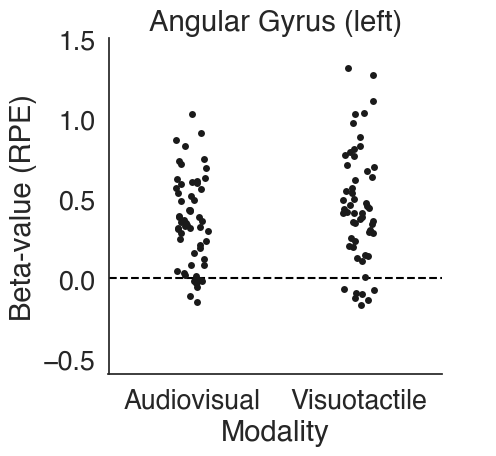

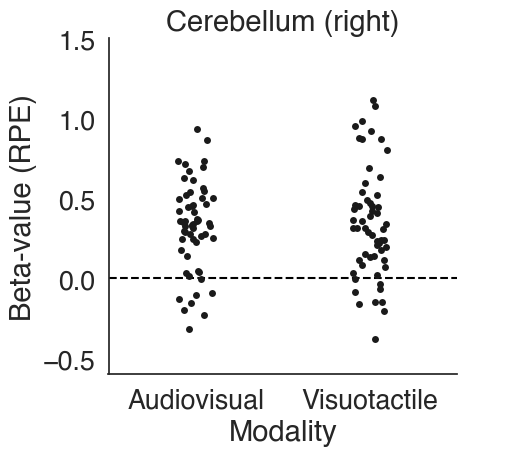

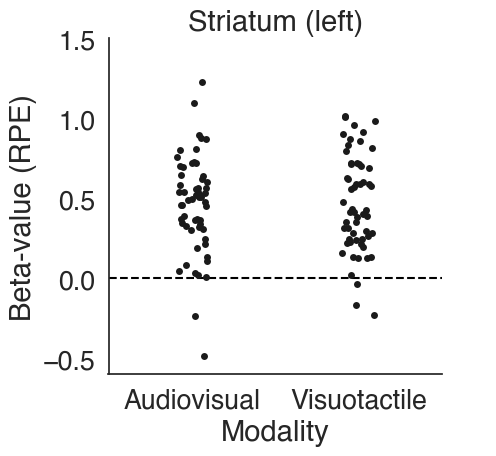

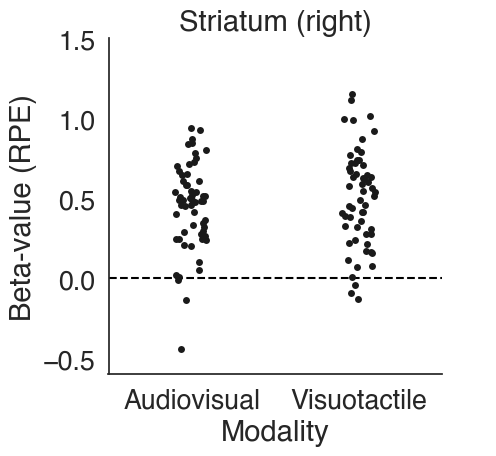

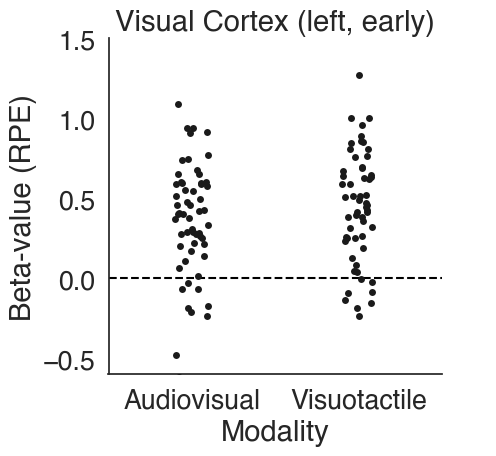

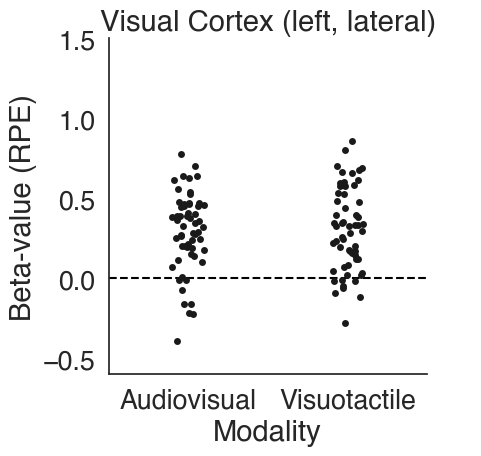

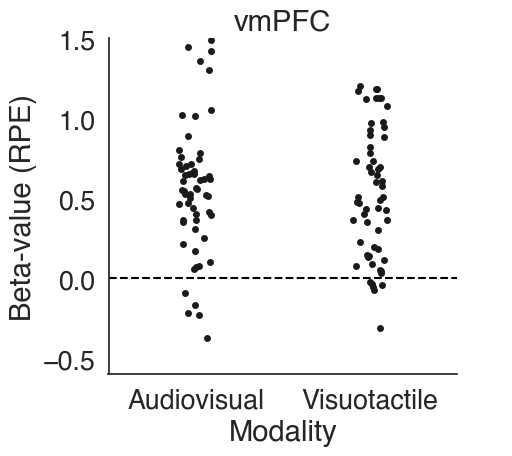

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('poster', )
sns.set(font='helvetica', font_scale=1.75, style='white')

# Assuming 'betas' is your DataFrame and it has the columns 'contrast', 'beta', and 'cluster_label'


figure_dir =  root_folder / 'figures'
figure_dir.mkdir(exist_ok=True, parents=True)


for cluster_label, b in betas.groupby('cluster_label'):
    g = sns.catplot(data=b, x='modality', y='beta', col='cluster_label', kind='strip', color='k')

    # Add a horizontal line at y=0
    g.map(plt.axhline, y=0, color='black', linestyle='--')

    # Overlay a point plot with error bars, without connecting the points, and make everything black
    # g.map_dataframe(sns.pointplot, x='contrast', y='beta', color='red', alpha=0.7, markersize=8, errorbar='se', linestyle='none')

    # Adjust the plot aesthetics if needed
    g.set_axis_labels("Contrast", "Beta")
    g.set_titles("{col_name}")
    g.set(ylabel='Beta-value (RPE)', ylim=(-0.6, 1.5), xlabel='Modality')

    plt.show()

    # Rewrite cluster_label to something that can go in a filename
    cluster_label = cluster_label.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
    g.savefig(figure_dir / f'rpe_betas_cluster_{cluster_label}.pdf', dpi=300, bbox_inches='tight', transparent=True)

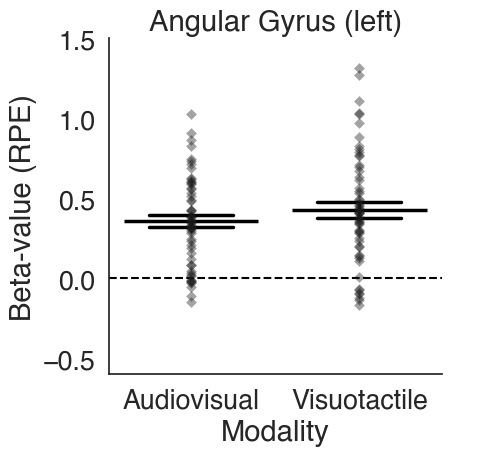

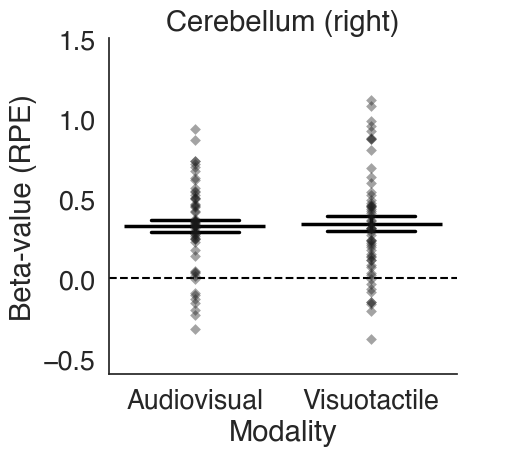

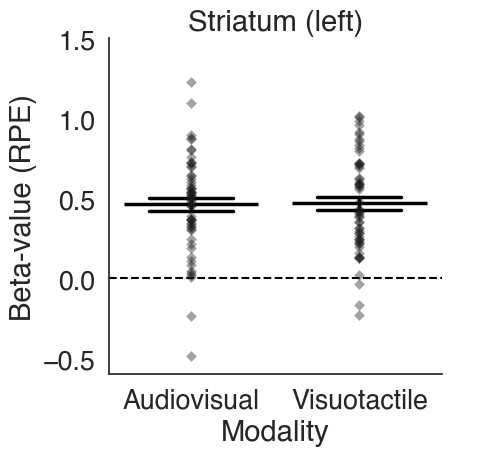

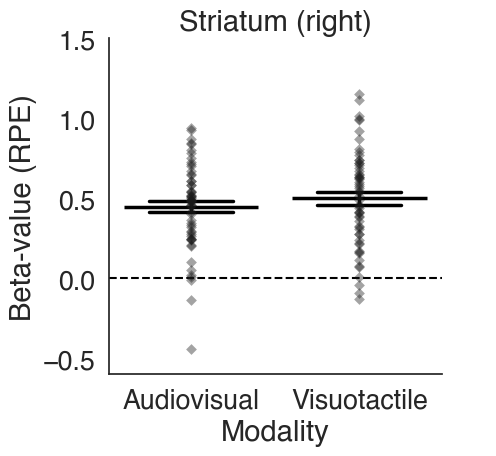

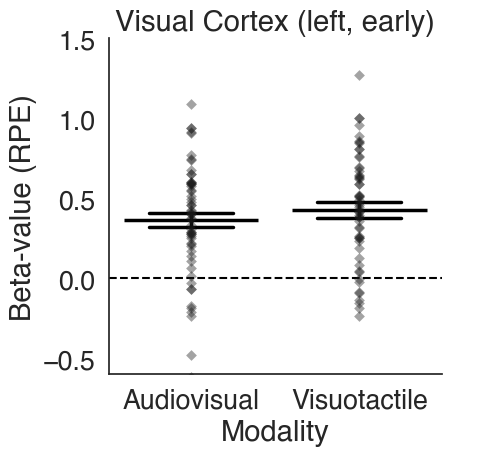

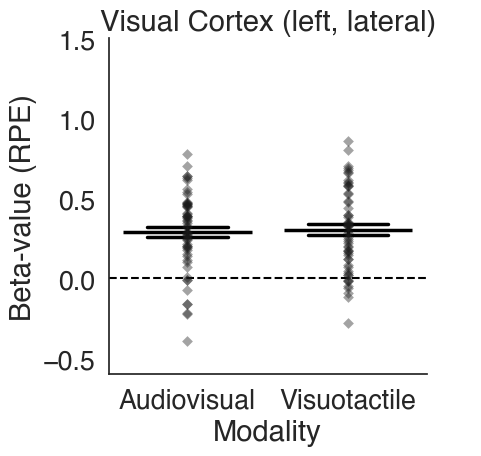

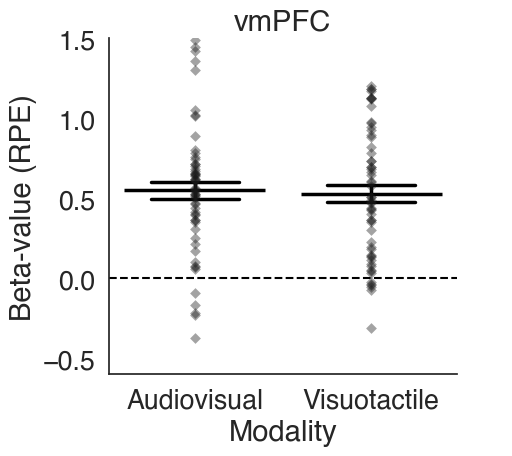

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_context('poster')
sns.set(font='helvetica', font_scale=1.75, style='white')

figure_dir = root_folder / 'figures'
figure_dir.mkdir(exist_ok=True, parents=True)

for cluster_label, b in betas.groupby('cluster_label'):
    g = sns.catplot(
        data=b,
        x='modality',
        y='beta',
        col='cluster_label',
        kind='strip',
        color='k',
        alpha=0.4,
        jitter=0.0,
        dodge=0.05,
        s=30,
        marker='D',  # Set marker to '+'

    )

    # Add a horizontal line at y=0
    g.map(plt.axhline, y=0, color='black', linestyle='--')

    # Overlay a point plot with SEM error bars, but hide the markers
    sns.pointplot(
        data=b,
        x='modality',
        y='beta',
        color='black',
        alpha=1.0,
        markersize=0,  # Hide the markers
        errorbar='se',
        linestyles='none',
        capsize=0.5,
        err_kws={'linewidth': 2.5},
        ax=g.axes[0, 0] if hasattr(g.axes, 'flatten') else g.ax
    )

    # Calculate means for each modality
    means = b.groupby('modality')['beta'].mean().values
    modalities = b['modality'].unique()

    # Overlay horizontal lines for the means
    ax = g.axes[0, 0] if hasattr(g.axes, 'flatten') else g.ax
    for i, mean in enumerate(means):
        ax.hlines(y=mean, xmin=i - 0.4, xmax=i + 0.4, colors='black', linewidth=2.5)

    g.set_axis_labels("Modality", "Beta-value (RPE)")
    g.set_titles("{col_name}")
    g.set(ylim=(-0.6, 1.5))

    # Save the figure
    cluster_label_clean = str(cluster_label).replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
    g.savefig(figure_dir / f'rpe_betas_cluster_{cluster_label_clean}.pdf', dpi=300, bbox_inches='tight', transparent=True)


# Get Surprise masks

In [3]:
base_dir = root_folder / 'nipype' / 'model2' 
# cluster_mapping = {
#     0: "Caudate, Putamen R",
#     2: "Caudate, Putamen L",
#     7: "Angular Gyrus L",
#     4: "Visual cortex (Mid, Lat Occipital) L",
#     3: "vmPFC",
#     8: "Visual Cortex (Lingual, Fusiform) L",
#     5: "Cerebellum R"
# }

cluster_fn = root_folder / 'nipype' / 'model2' / '2ndLevel' / 'cluster_SnPM_SecondLevel_con5' / 'SnPM_filtered_t3_1_pos.nii'

df, clusters = get_clusters_table(cluster_fn, stat_threshold=3.1, return_label_maps=True)

df = df[df['Cluster Size (mm3)'] != '']
min_cluster_size = 75
df['Cluster size (voxels)'] = np.round(df['Cluster Size (mm3)'].astype(float) / (15.5)).astype(int)
df = df[df['Cluster size (voxels)'] > min_cluster_size]

df[['X', 'Y', 'Z']] = df[['X', 'Y', 'Z']].astype(int)

df.rename(columns={'Cluster ID': 'Cluster Index', 'X':'Max X', 'Y':'Max Y', 'Z':'Max Z',
                   'Peak Stat':'T', 'Cluster size (voxels)': 'Voxels'}, inplace=True)

df = df[['Cluster Index', 'Voxels', 'T', 'Max X', 'Max Y', 'Max Z']]

df['T'] = df['T'].round(2)
df['P_FWE_corr'] = 0.0002 
df.to_csv(base_dir / 'ROI' / 'snpm_stats_con5_3_1_pos.csv')

clusters = clusters[0]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_22344/1075251833.py:14: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  df, clusters = get_clusters_table(cluster_fn, stat_threshold=3.1, return_label_maps=True)


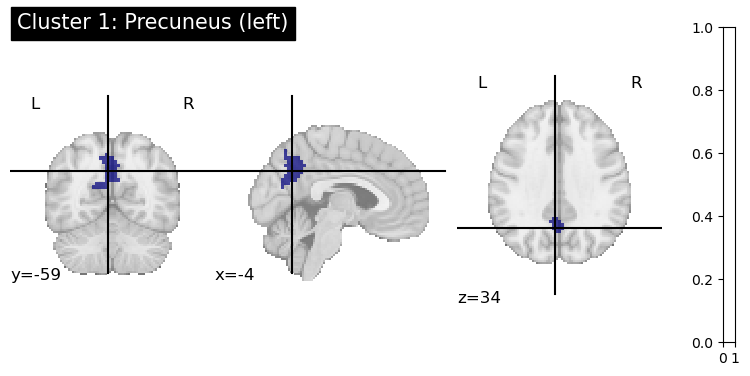

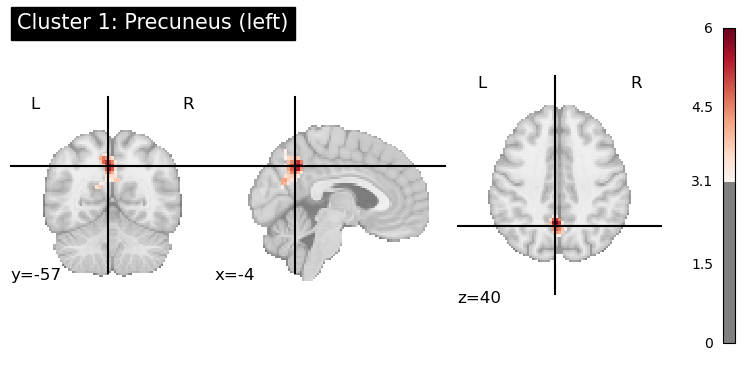

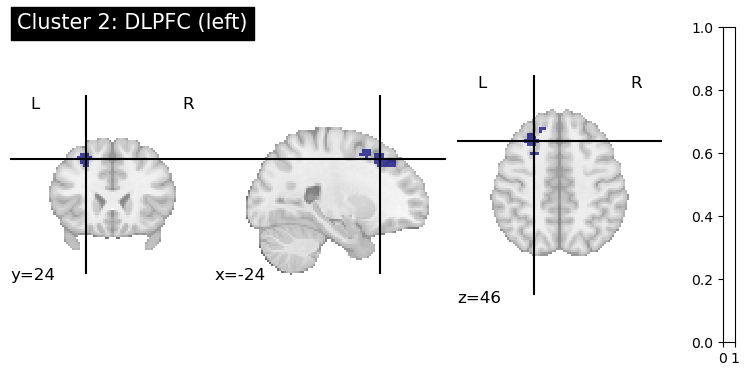

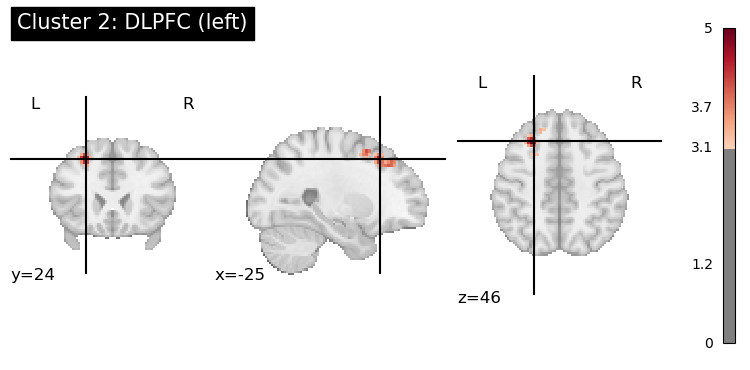

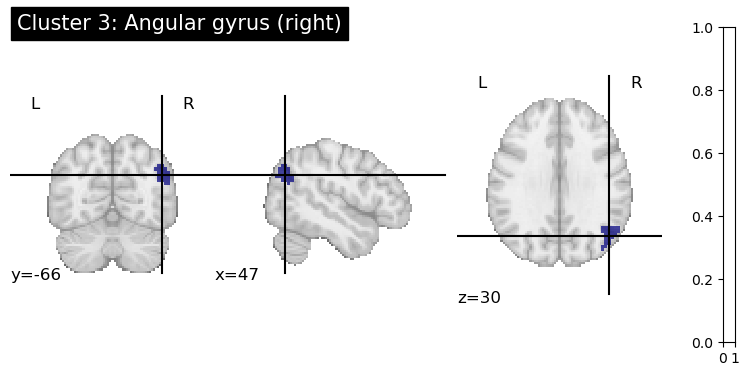

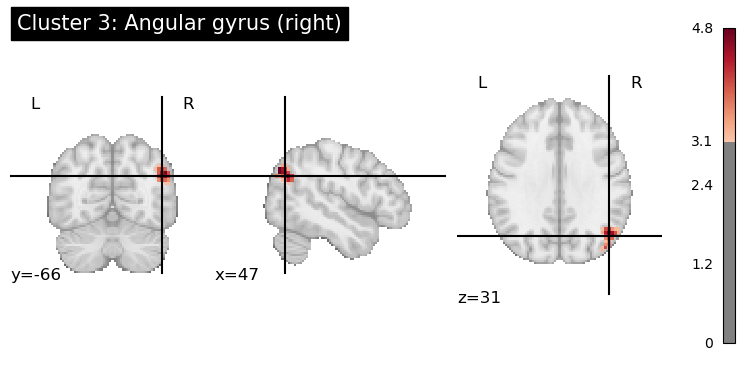

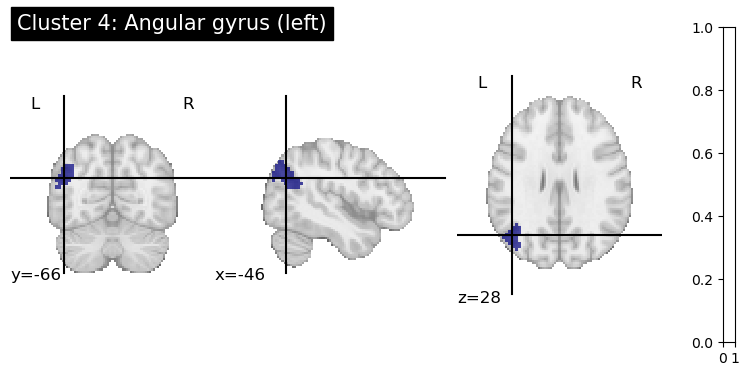

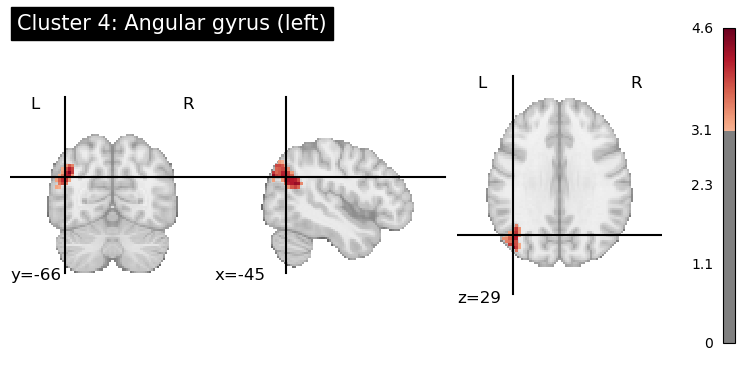

In [4]:

zmaps = []

cluster_labels = ['Precuneus (left)', 'DLPFC (left)', 'Angular gyrus (right)', 'Angular gyrus (left)' ]

for i, cluster in enumerate(df['Cluster Index'].unique()[:len(cluster_labels)]):
    zmap = image.load_img(cluster_fn)
    zmap = image.math_img("np.nan_to_num(zmap)", zmap=zmap)

    c = image.math_img(f"clusters == {cluster}", clusters=clusters)
    plotting.plot_roi(c, title=f'Cluster {i+1}: {cluster_labels[i]}' )

    target_fn = base_dir / 'ROI' / f'cluster_{cluster}_con5_3_1_pos.nii'

    c.to_filename(target_fn)

    zmap = image.math_img(f"zmap * (clusters == {cluster}).squeeze()", zmap=zmap, clusters=clusters)
    zmap.to_filename(target_fn.with_suffix('.zmap.nii.gz'))

    plotting.plot_stat_map(zmap, title=f'Cluster {i+1}: {cluster_labels[i]}', threshold=3.1, colorbar=True)


    zmaps.append(zmap)

combined_zmap = image.math_img('im.sum(-1)', im=image.concat_imgs(zmaps))
combined_zmap.to_filename(base_dir / 'ROI' / 'combined_clusters_con5_3_1_pos.zmap.nii.gz')


In [5]:
from nilearn.input_data import NiftiMasker

subjects = range(1,65)
subjects = [str(sub).zfill(2) for sub in subjects if sub not in [8, 13, 16, 31, 32, 44]]

def get_mean_beta_surprise(subject, cluster, contrast, model):
    assert model == 'model2', "Only model2 is supported"
    assert contrast in [2, 3]

    fn = root_folder / 'nipype' / model / '1stLevel' / f'sub-{subject}' / f'con_{contrast:04d}.nii'
    mask = root_folder / 'nipype' / model / 'ROI' / f'cluster_{cluster}_con5_3_1_pos.nii'

    masker = NiftiMasker(mask_img=mask, )
    return masker.fit_transform(fn).mean()

from tqdm.contrib.itertools import product

betas_surprise = []

for subject, cluster, contrast in product(subjects, range(1, 5), [2, 3]):
    betas_surprise.append([subject, cluster, contrast, get_mean_beta_surprise(subject, cluster, contrast, 'model2')])

import pandas as pd
betas_surprise = pd.DataFrame(betas_surprise, columns=['subject', 'cluster', 'contrast', 'beta'])
betas_surprise['cluster_label'] = betas_surprise['cluster'].apply(lambda x: cluster_labels[x-1])
betas_surprise['modality'] = betas_surprise['contrast'].map({2: 'Audiovisual', 3: 'Visuotactile'})

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_22344/2303711514.py:1: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiMasker
/Users/gdehol/mambaforge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 464/464 [01:45<00:00,  4.42it/s]


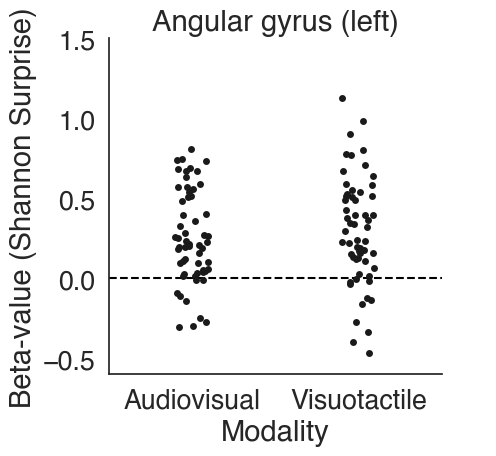

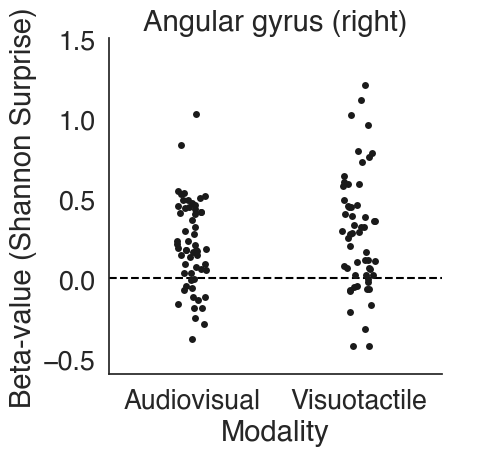

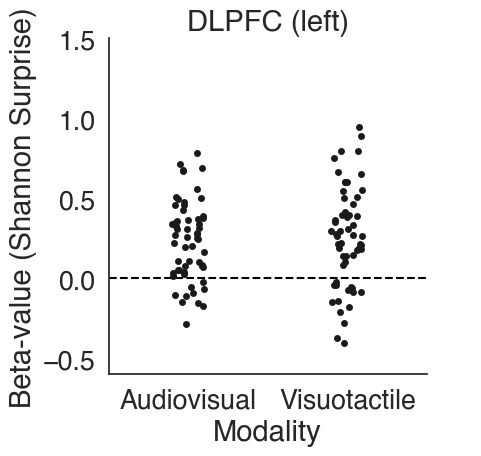

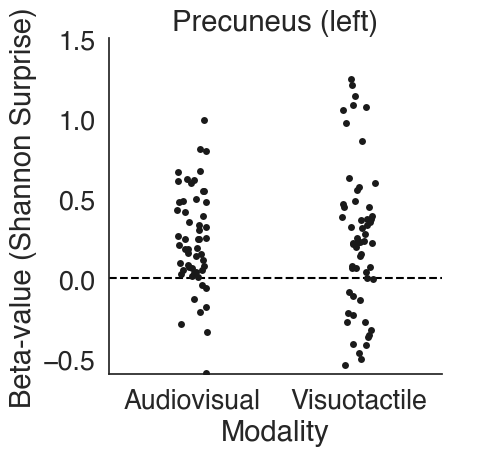

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('poster', )
sns.set(font='helvetica', font_scale=1.75, style='white')

# Assuming 'betas' is your DataFrame and it has the columns 'contrast', 'beta', and 'cluster_label'


figure_dir =  root_folder / 'figures'
figure_dir.mkdir(exist_ok=True, parents=True)


for cluster_label, b in betas_surprise.groupby('cluster_label'):
    g = sns.catplot(data=b, x='modality', y='beta', col='cluster_label', kind='strip', color='k')

    # Add a horizontal line at y=0
    g.map(plt.axhline, y=0, color='black', linestyle='--')

    # Overlay a point plot with error bars, without connecting the points, and make everything black
    # g.map_dataframe(sns.pointplot, x='contrast', y='beta', color='red', alpha=0.7, markersize=8, errorbar='se', linestyle='none')

    # Adjust the plot aesthetics if needed
    g.set_axis_labels("Contrast", "Beta")
    g.set_titles("{col_name}")
    g.set(ylabel='Beta-value (Shannon Surprise)', ylim=(-0.6, 1.5), xlabel='Modality')

    plt.show()

    # Rewrite cluster_label to something that can go in a filename
    cluster_label = cluster_label.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
    g.savefig(figure_dir / f'surprise_betas_cluster_{cluster_label}.pdf', dpi=300, bbox_inches='tight', transparent=True)

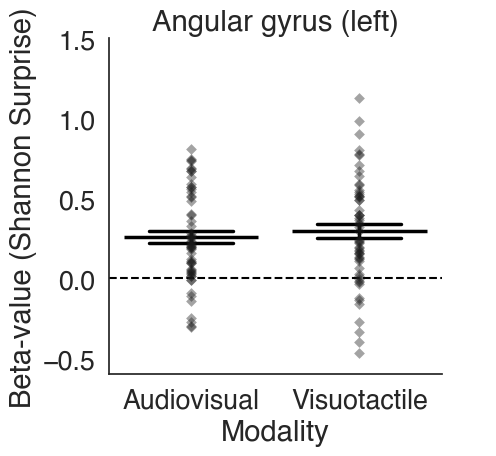

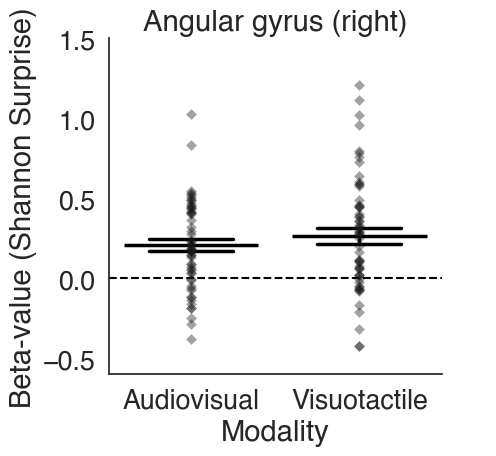

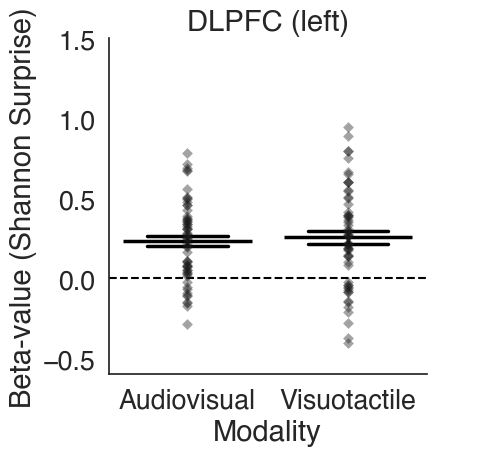

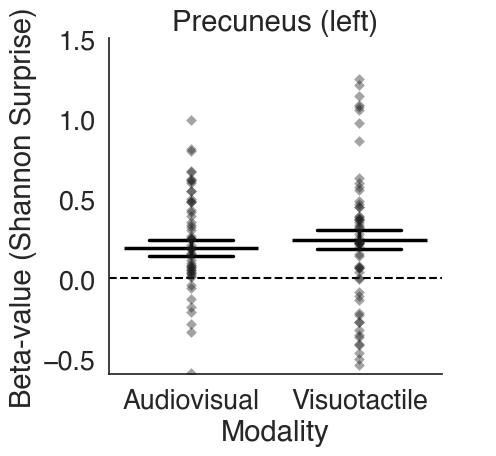

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_context('poster')
sns.set(font='helvetica', font_scale=1.75, style='white')

figure_dir = root_folder / 'figures'
figure_dir.mkdir(exist_ok=True, parents=True)

for cluster_label, b in betas_surprise.groupby('cluster_label'):
    g = sns.catplot(
        data=b,
        x='modality',
        y='beta',
        col='cluster_label',
        kind='strip',
        color='k',
        alpha=0.4,
        jitter=0.0,
        dodge=0.05,
        s=30,
        marker='D',  # Set marker to '+'

    )

    # Add a horizontal line at y=0
    g.map(plt.axhline, y=0, color='black', linestyle='--')

    # Overlay a point plot with SEM error bars, but hide the markers
    sns.pointplot(
        data=b,
        x='modality',
        y='beta',
        color='black',
        alpha=1.0,
        markersize=0,  # Hide the markers
        errorbar='se',
        linestyles='none',
        capsize=0.5,
        err_kws={'linewidth': 2.5},
        ax=g.axes[0, 0] if hasattr(g.axes, 'flatten') else g.ax
    )

    # Calculate means for each modality
    means = b.groupby('modality')['beta'].mean().values
    modalities = b['modality'].unique()

    # Overlay horizontal lines for the means
    ax = g.axes[0, 0] if hasattr(g.axes, 'flatten') else g.ax
    for i, mean in enumerate(means):
        ax.hlines(y=mean, xmin=i - 0.4, xmax=i + 0.4, colors='black', linewidth=2.5)

    g.set_axis_labels("Modality", "Beta-value (Shannon Surprise)")
    g.set_titles("{col_name}")
    g.set(ylim=(-0.6, 1.5))

    # Save the figure
    cluster_label_clean = str(cluster_label).replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
    g.savefig(figure_dir / f'surprise_betas_cluster_{cluster_label_clean}.pdf', dpi=300, bbox_inches='tight', transparent=True)


# Negative RPE

In [8]:
base_dir = root_folder / 'nipype' / 'model2' 
cluster_mapping = {
    0: "Caudate, Putamen R",
    2: "Caudate, Putamen L",
}

cluster_fn = root_folder / 'nipype' / 'model2' / '2ndLevel' / 'cluster_SnPM_SecondLevel_con1' / 'SnPM_filtered_t3_1_neg.nii'

df, clusters = get_clusters_table(cluster_fn, stat_threshold=3.1, return_label_maps=True)

df = df[df['Cluster Size (mm3)'] != '']
min_cluster_size = 67
df['Cluster size (voxels)'] = np.round(df['Cluster Size (mm3)'].astype(float) / (15.5)).astype(int)
df = df[df['Cluster size (voxels)'] > min_cluster_size]

df[['X', 'Y', 'Z']] = df[['X', 'Y', 'Z']].astype(int)

df.rename(columns={'Cluster ID': 'Cluster Index', 'X':'Max X', 'Y':'Max Y', 'Z':'Max Z',
                   'Peak Stat':'T', 'Cluster size (voxels)': 'Voxels'}, inplace=True)

df = df[['Cluster Index', 'Voxels', 'T', 'Max X', 'Max Y', 'Max Z']]

df['T'] = df['T'].round(2)
df['P_FWE_corr'] = 0.0002 
df.to_csv(base_dir / 'ROI' / 'snpm_stats_con1_3_1_neg.csv')

clusters = clusters[0]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_22344/1732696123.py:9: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  df, clusters = get_clusters_table(cluster_fn, stat_threshold=3.1, return_label_maps=True)


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_50765/3773626036.py:2: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  brain_mask = image.resample_to_img(brain_mask, zmap, interpolation='nearest')
/Users/gdehol/mambaforge/lib/python3.10/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


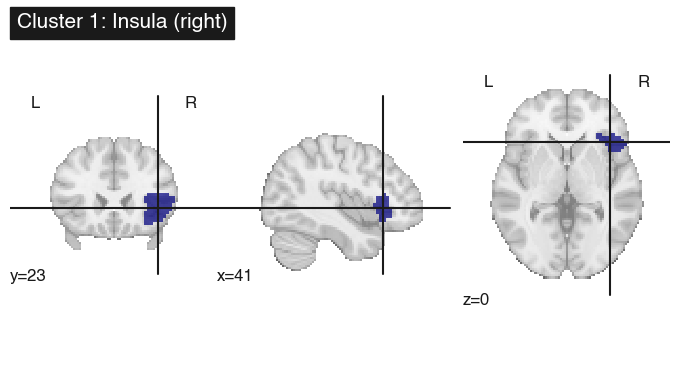

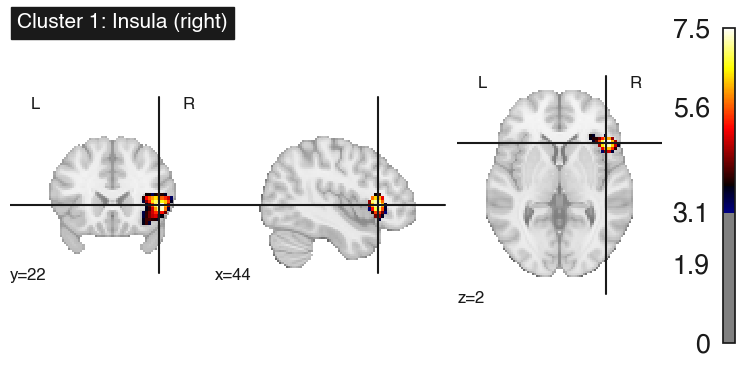

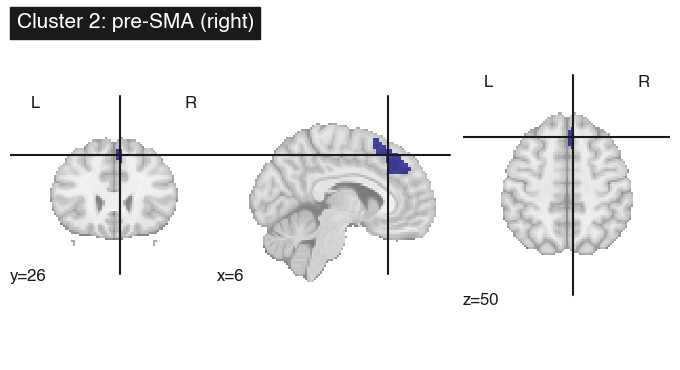

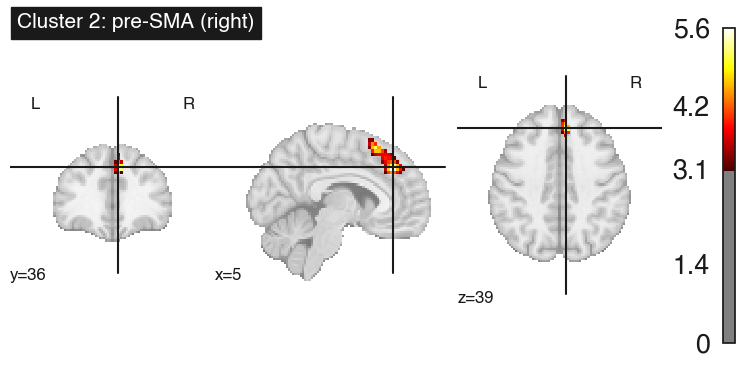

In [35]:
brain_mask = '/usr/local/fsl/data/standard/MNI152_T1_1mm_brain_mask.nii.gz'
brain_mask = image.resample_to_img(brain_mask, zmap, interpolation='nearest')
brain_mask = image.math_img("brain_mask > 0", brain_mask=brain_mask)
clusters = image.math_img("clusters * brain_mask", clusters=clusters, brain_mask=brain_mask)

cluster_labels = ['Insula (right)', 'pre-SMA (right)']

for i, cluster in enumerate(df['Cluster Index'].unique()[:len(cluster_labels)]):
    zmap = image.load_img(cluster_fn)
    zmap = image.math_img("np.nan_to_num(zmap)", zmap=zmap)

    clusters = image.math_img("clusters * brain_mask", clusters=clusters, brain_mask=brain_mask)

    c = image.math_img(f"clusters == {cluster}", clusters=clusters)
    plotting.plot_roi(c, title=f'Cluster {i+1}: {cluster_labels[i]}' )

    target_fn = base_dir / 'ROI' / f'cluster_{cluster}_con1_3_1_neg.nii'

    c.to_filename(target_fn)

    zmap = image.math_img(f"zmap * (clusters == {cluster}).squeeze()", zmap=zmap, clusters=clusters)
    zmap.to_filename(target_fn.with_suffix('.zmap.nii.gz'))

    plotting.plot_stat_map(zmap, title=f'Cluster {i+1}: {cluster_labels[i]}', threshold=3.1, colorbar=True)

In [36]:
from nilearn.input_data import NiftiMasker

subjects = range(1,65)
subjects = [str(sub).zfill(2) for sub in subjects if sub not in [8, 13, 16, 31, 32, 44]]

def get_mean_beta_rpe_neg(subject, cluster, contrast, model):
    assert model == 'model2', "Only model2 is supported"
    assert contrast in [2, 3]

    fn = root_folder / 'nipype' / model / '1stLevel' / f'sub-{subject}' / f'con_{contrast:04d}.nii'
    mask = root_folder / 'nipype' / model / 'ROI' / f'cluster_{cluster}_con1_3_1_neg.nii'

    masker = NiftiMasker(mask_img=mask, )
    return masker.fit_transform(fn).mean()

from tqdm.contrib.itertools import product

betas_rpe_neg = []

for subject, cluster, contrast in product(subjects, range(1, 3), [2, 3]):
    betas_rpe_neg.append([subject, cluster, contrast, get_mean_beta_rpe_neg(subject, cluster, contrast, 'model2')])

import pandas as pd
betas_rpe_neg = pd.DataFrame(betas_rpe_neg, columns=['subject', 'cluster', 'contrast', 'beta'])
betas_rpe_neg['cluster_label'] = betas_rpe_neg['cluster'].apply(lambda x: cluster_labels[x-1])
betas_rpe_neg['modality'] = betas_rpe_neg['contrast'].map({2: 'Audiovisual', 3: 'Visuotactile'})

  0%|          | 0/232 [00:00<?, ?it/s]

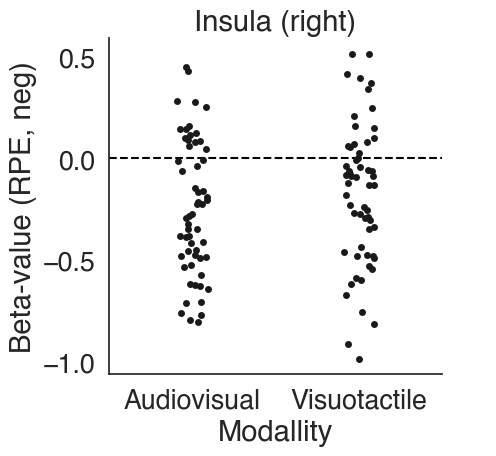

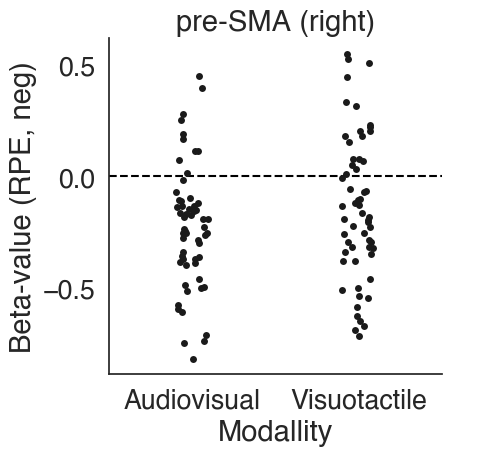

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('poster', )
sns.set(font='helvetica', font_scale=1.75, style='white')

# Assuming 'betas' is your DataFrame and it has the columns 'contrast', 'beta', and 'cluster_label'


figure_dir =  root_folder / 'figures'
figure_dir.mkdir(exist_ok=True, parents=True)


for cluster_label, b in betas_rpe_neg.groupby('cluster_label'):
    g = sns.catplot(data=b, x='modality', y='beta', col='cluster_label', kind='strip', color='k')

    # Add a horizontal line at y=0
    g.map(plt.axhline, y=0, color='black', linestyle='--')

    # Overlay a point plot with error bars, without connecting the points, and make everything black
    # g.map_dataframe(sns.pointplot, x='contrast', y='beta', color='red', alpha=0.7, markersize=8, errorbar='se', linestyle='none')

    # Adjust the plot aesthetics if needed
    g.set_axis_labels("Contrast", "Beta")
    g.set_titles("{col_name}")
    g.set(ylabel='Beta-value (RPE, neg)', xlabel='Modallity')

    plt.show()

    # Rewrite cluster_label to something that can go in a filename
    cluster_label = cluster_label.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
    g.savefig(figure_dir / f'rpe_neg_betas_cluster_{cluster_label}.pdf', dpi=300, bbox_inches='tight', transparent=True)

# Unsigned RPE

In [9]:
base_dir = root_folder / 'nipype' / 'model7' 

cluster_fn = root_folder / 'nipype' / 'model7' / '2ndLevel' / 'cluster_SnPM_SecondLevel_con1' / 'SnPM_filtered_t4_0_pos.nii'


df, clusters = get_clusters_table(cluster_fn, stat_threshold=3.1, return_label_maps=True)

df = df[df['Cluster Size (mm3)'] != '']
min_cluster_size = 9
df['Cluster size (voxels)'] = np.round(df['Cluster Size (mm3)'].astype(float) / (15.5)).astype(int)
df = df[df['Cluster size (voxels)'] > min_cluster_size]

df[['X', 'Y', 'Z']] = df[['X', 'Y', 'Z']].astype(int)

df.rename(columns={'Cluster ID': 'Cluster Index', 'X':'Max X', 'Y':'Max Y', 'Z':'Max Z',
                   'Peak Stat':'T', 'Cluster size (voxels)': 'Voxels'}, inplace=True)

df = df[['Cluster Index', 'Voxels', 'T', 'Max X', 'Max Y', 'Max Z']]

df['T'] = df['T'].round(2)
df['P_FWE_corr'] = 0.0002 


roi_dir = base_dir / 'ROI'
roi_dir.mkdir(exist_ok=True, parents=True)
df.to_csv(roi_dir / 'snpm_stats_con1_4_0_pos.csv')

clusters = clusters[0]

zmap = image.load_img(cluster_fn)
zmap = image.math_img("np.nan_to_num(zmap)", zmap=zmap)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_22344/1726179805.py:6: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  df, clusters = get_clusters_table(cluster_fn, stat_threshold=3.1, return_label_maps=True)


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_22344/6101309.py:2: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  brain_mask = image.resample_to_img(brain_mask, zmap, interpolation='nearest')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_22344/6101309.py:2: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  brain_mask = image.resample_to_img(brain_mask, zmap, interpolation='nearest')


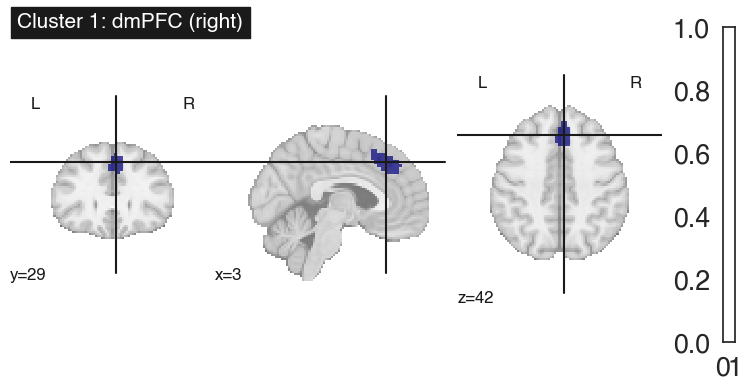

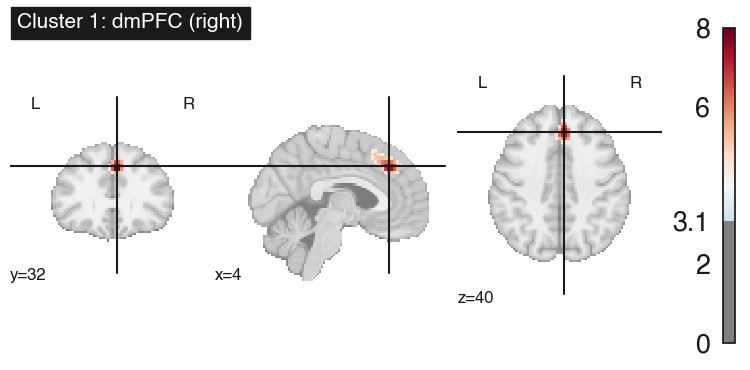

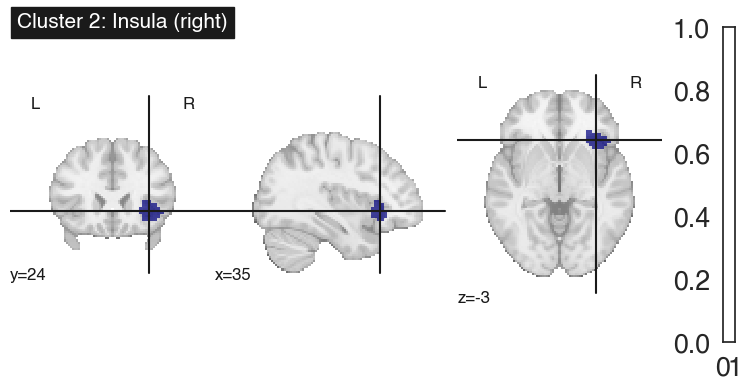

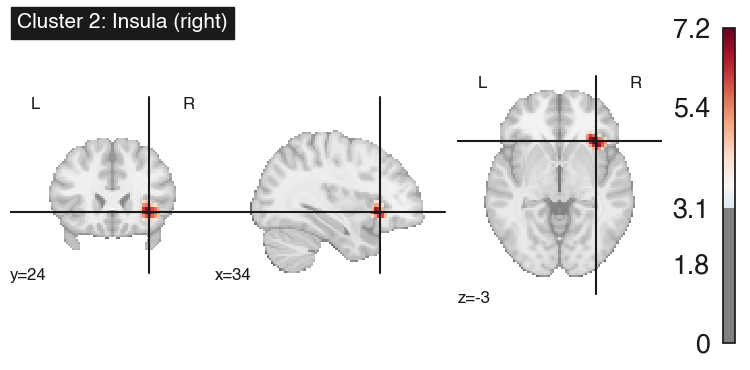

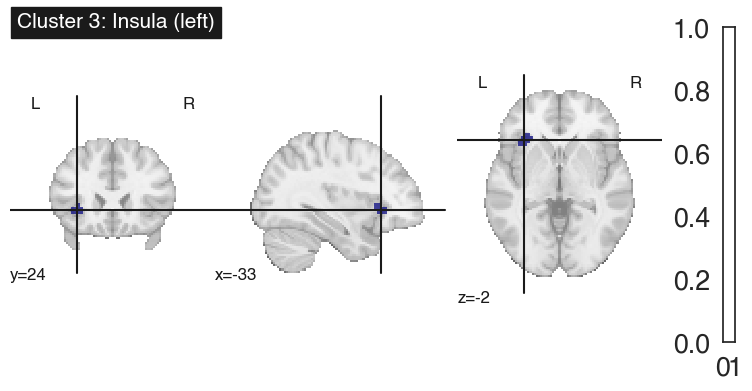

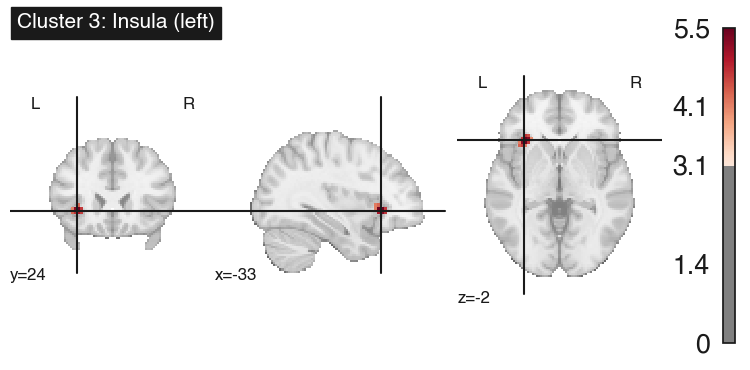

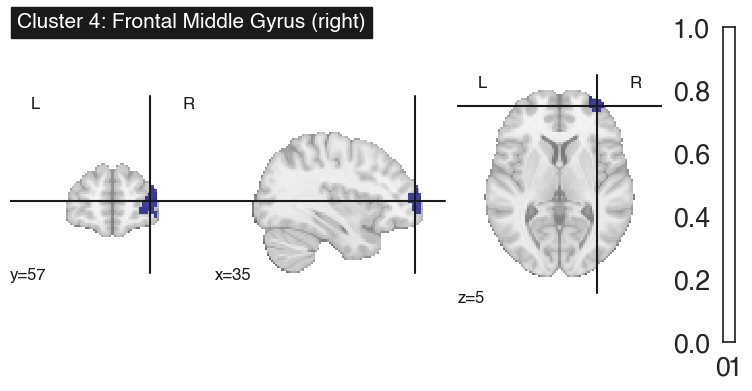

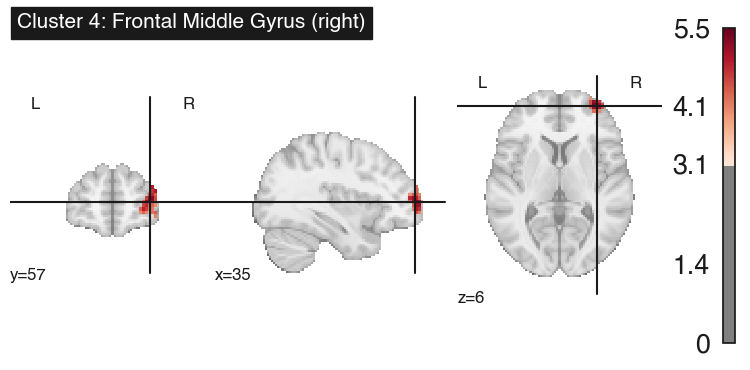

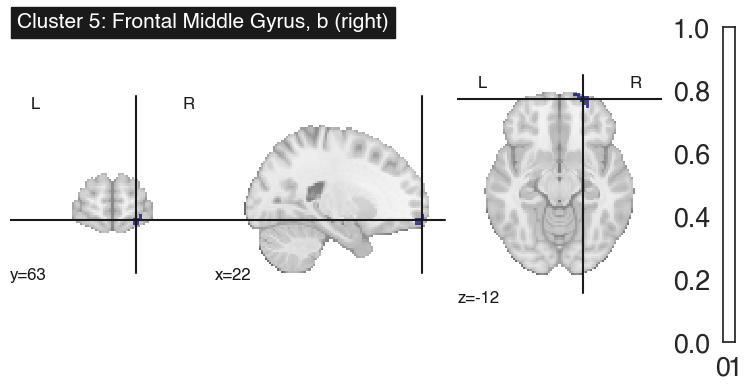

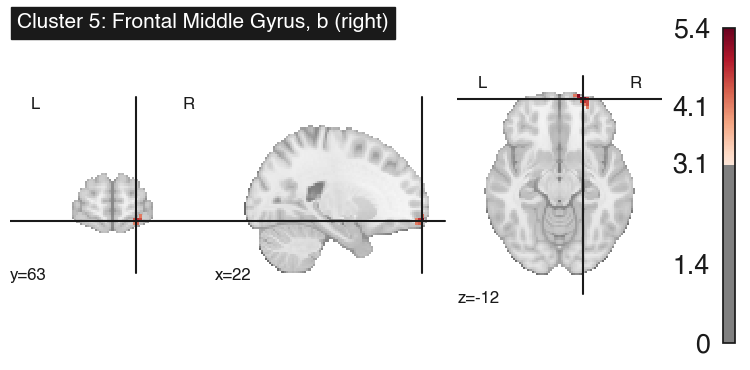

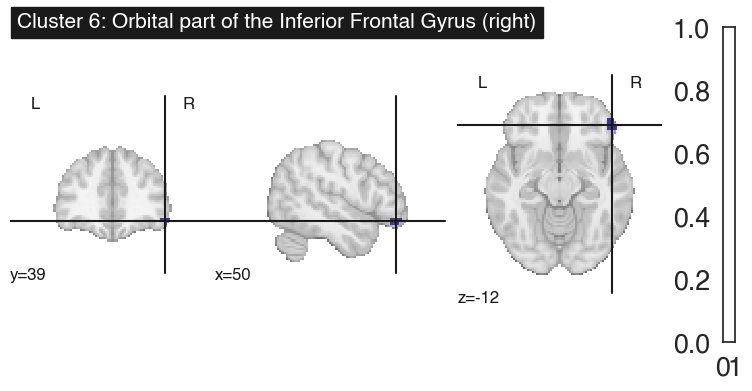

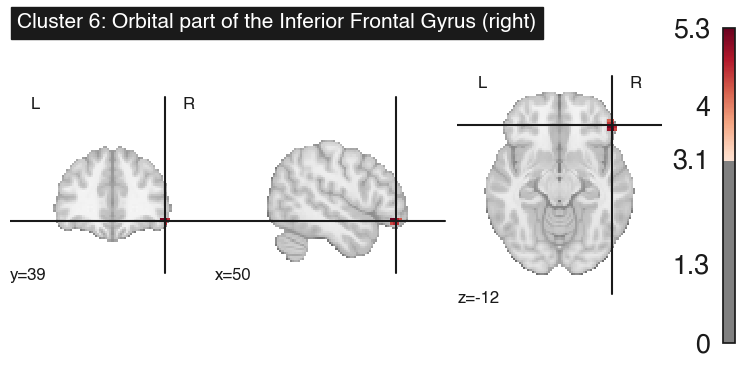

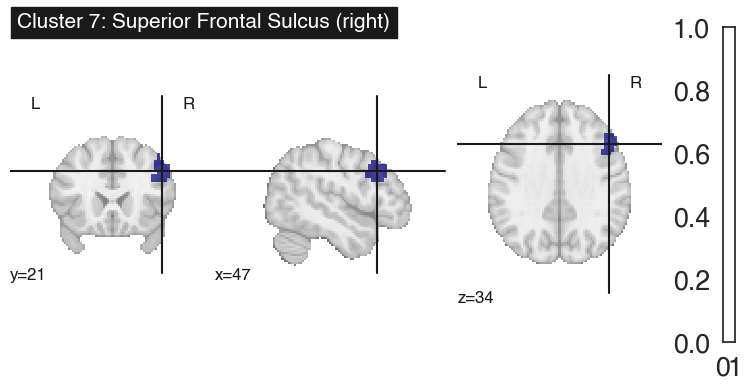

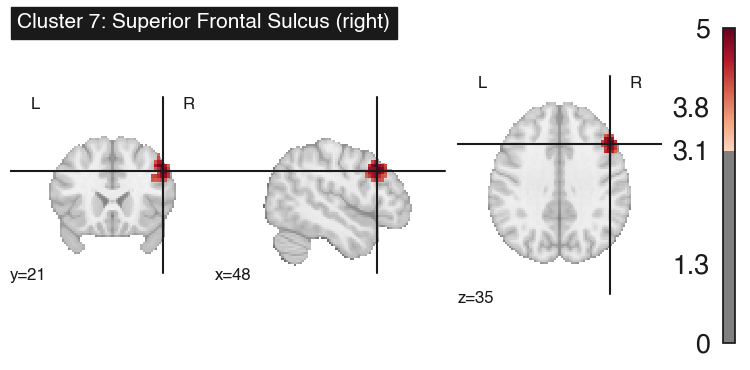

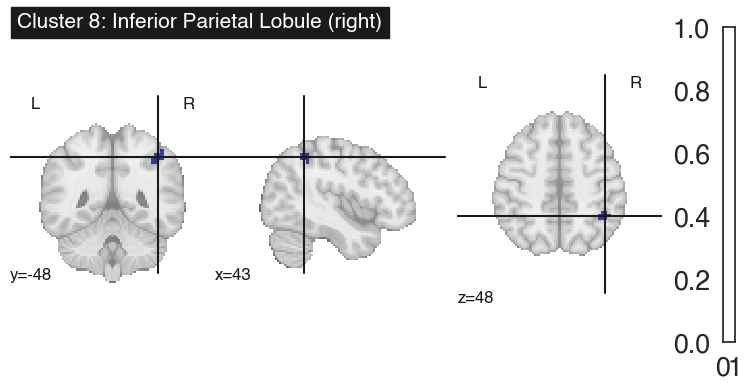

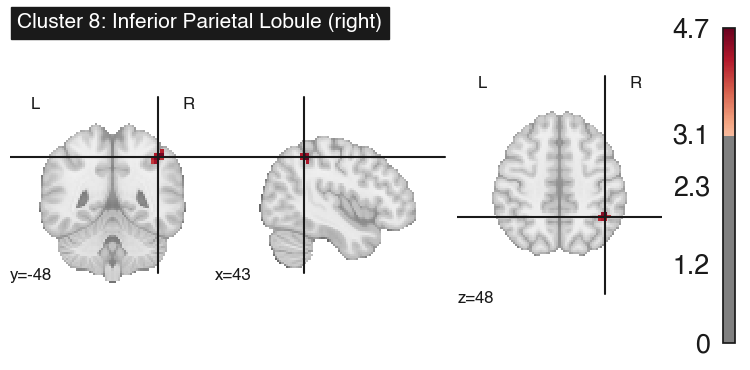

In [10]:
brain_mask = '/usr/local/fsl/data/standard/MNI152_T1_1mm_brain_mask.nii.gz'
brain_mask = image.resample_to_img(brain_mask, zmap, interpolation='nearest')
brain_mask = image.math_img("brain_mask > 0", brain_mask=brain_mask)
clusters = image.math_img("clusters * brain_mask", clusters=clusters, brain_mask=brain_mask)

# cluster_labels = ['dmPFC (right)', 'Insula (right)', 'Angular gyrus (right)',]
cluster_labels= [f'Cluster {i+1}' for i in range(len(df))]
cluster_labels = ['dmPFC (right)', 'Insula (right)', 'Insula (left)', 'Frontal Middle Gyrus (right)',
                  'Frontal Middle Gyrus, b (right)', 'Orbital part of the Inferior Frontal Gyrus (right)',
                   'Superior Frontal Sulcus (right)', 'Inferior Parietal Lobule (right)']

zmaps = []

for i, cluster in enumerate(df['Cluster Index'].unique()[:len(cluster_labels)]):
    zmap = image.load_img(cluster_fn)
    zmap = image.math_img("np.nan_to_num(zmap)", zmap=zmap)

    clusters = image.math_img("clusters * brain_mask", clusters=clusters, brain_mask=brain_mask)

    c = image.math_img(f"clusters == {cluster}", clusters=clusters)
    plotting.plot_roi(c, title=f'Cluster {i+1}: {cluster_labels[i]}' )

    target_fn = base_dir / 'ROI' / f'cluster_{cluster}_con1_4_0_pos.nii'

    c.to_filename(target_fn)

    zmap = image.math_img(f"zmap * (clusters == {cluster}).squeeze()", zmap=zmap, clusters=clusters)
    zmap.to_filename(target_fn.with_suffix('.zmap.nii.gz'))

    plotting.plot_stat_map(zmap, title=f'Cluster {i+1}: {cluster_labels[i]}', threshold=3.1, colorbar=True)
    zmaps.append(zmap)

combined_zmap = image.math_img('im.sum(-1)', im=image.concat_imgs(zmaps))

combined_zmap.to_filename(base_dir / 'ROI' / 'combined_clusters_con1_4_0_pos.zmap.nii.gz')

In [11]:
from nilearn.input_data import NiftiMasker

subjects = range(1,65)
subjects = [str(sub).zfill(2) for sub in subjects if sub not in [8, 13, 16, 31, 32, 44]]

def get_mean_beta_urpe(subject, cluster, contrast, model):
    assert model == 'model7', "Only model7 is supported"
    assert contrast in [2, 3]

    fn = root_folder / 'nipype' / model / '1stLevel' / f'sub-{subject}' / f'con_{contrast:04d}.nii'
    mask = root_folder / 'nipype' / model / 'ROI' / f'cluster_{cluster}_con1_3_1_neg.nii'

    try:
        masker = NiftiMasker(mask_img=mask, )
        return masker.fit_transform(fn).mean()
    except ValueError as e:
        print(f"File not found for subject {subject}, cluster {cluster}, contrast {contrast}: {e}")
        return np.nan

from tqdm.contrib.itertools import product

betas_urpre = []

for subject, cluster, contrast in product(subjects, range(1, 9), [2, 3]):
    betas_urpre.append([subject, cluster, contrast, get_mean_beta_urpe(subject, cluster, contrast, 'model7')])

import pandas as pd
betas_urpre = pd.DataFrame(betas_urpre, columns=['subject', 'cluster', 'contrast', 'beta'])
betas_urpre['cluster_label'] = betas_urpre['cluster'].apply(lambda x: cluster_labels[x-1])
betas_urpre['modality'] = betas_urpre['contrast'].map({2: 'Audiovisual', 3: 'Visuotactile'})

100%|██████████| 928/928 [04:12<00:00,  3.68it/s]


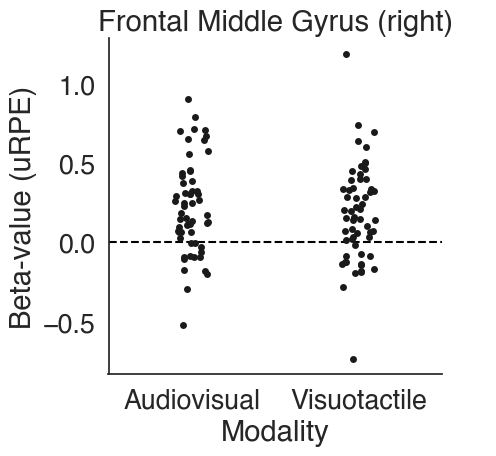

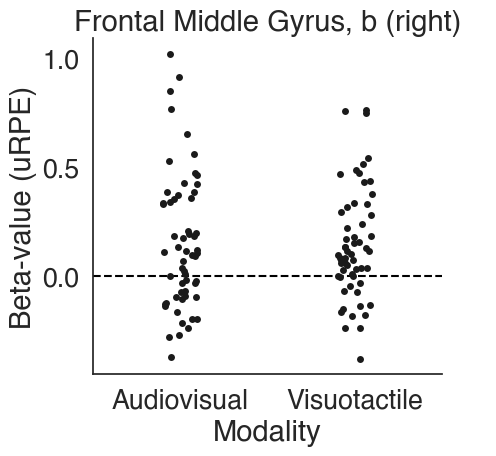

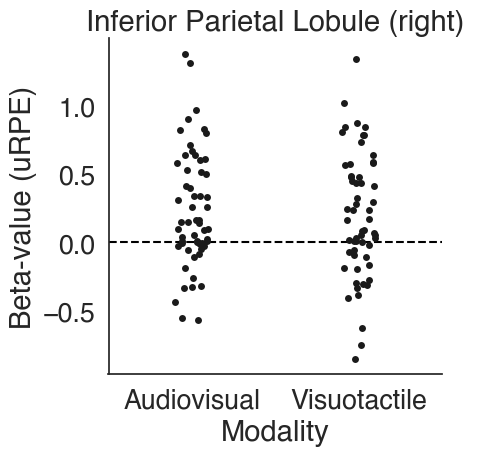

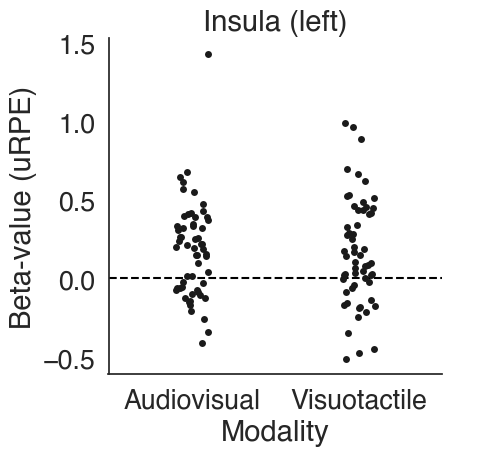

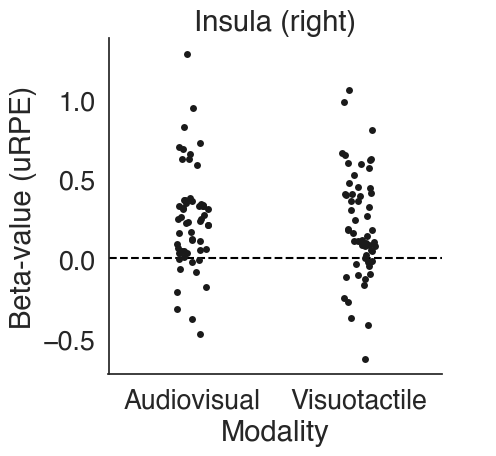

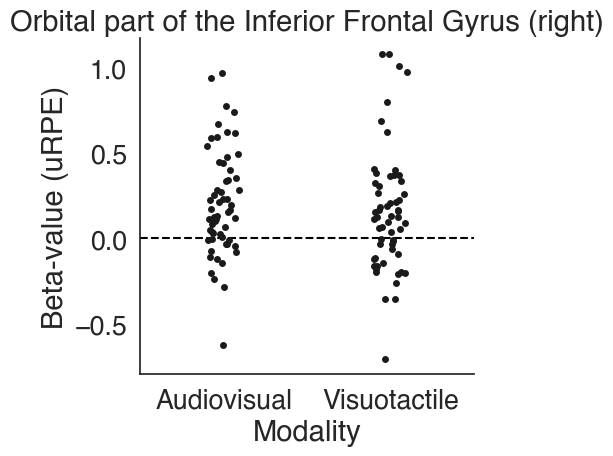

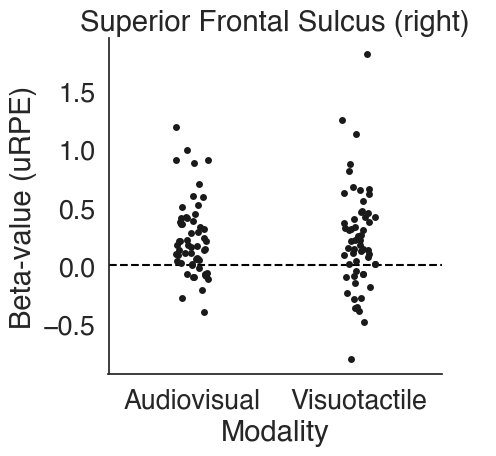

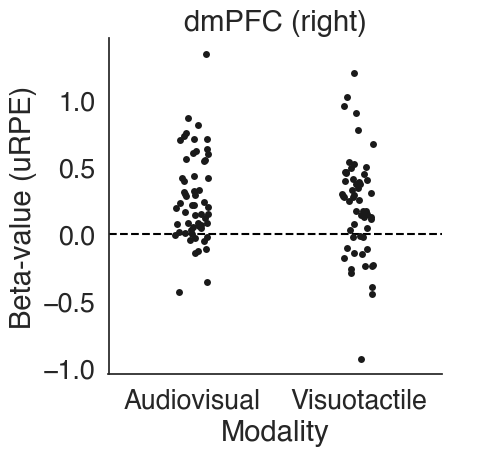

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('poster', )
sns.set(font='helvetica', font_scale=1.75, style='white')

# Assuming 'betas' is your DataFrame and it has the columns 'contrast', 'beta', and 'cluster_label'

figure_dir =  root_folder / 'figures'
figure_dir.mkdir(exist_ok=True, parents=True)


for cluster_label, b in betas_urpre.groupby('cluster_label'):
    g = sns.catplot(data=b, x='modality', y='beta', col='cluster_label', kind='strip', color='k')

    # Add a horizontal line at y=0
    g.map(plt.axhline, y=0, color='black', linestyle='--')

    # Overlay a point plot with error bars, without connecting the points, and make everything black
    # g.map_dataframe(sns.pointplot, x='contrast', y='beta', color='red', alpha=0.7, markersize=8, errorbar='se', linestyle='none')

    # Adjust the plot aesthetics if needed
    g.set_axis_labels("Contrast", "Beta")
    g.set_titles("{col_name}")
    g.set(ylabel='Beta-value (uRPE)', xlabel='Modality')

    plt.show()

    # Rewrite cluster_label to something that can go in a filename
    cluster_label = cluster_label.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
    g.savefig(figure_dir / f'urpe_urpe_betas_cluster_{cluster_label}.pdf', dpi=300, bbox_inches='tight', transparent=True)

In [13]:
# Replace cluster_label "dmPFC (rightl)" with "dmPFC (right)" in betas
betas_urpre['cluster_label'] = betas_urpre['cluster_label'].replace('dmPFC (rightl)', 'dmPFC (right)')

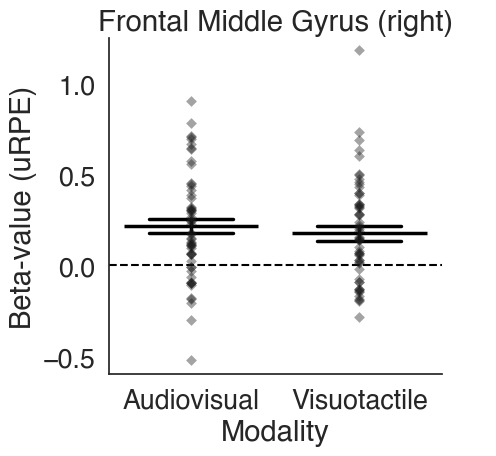

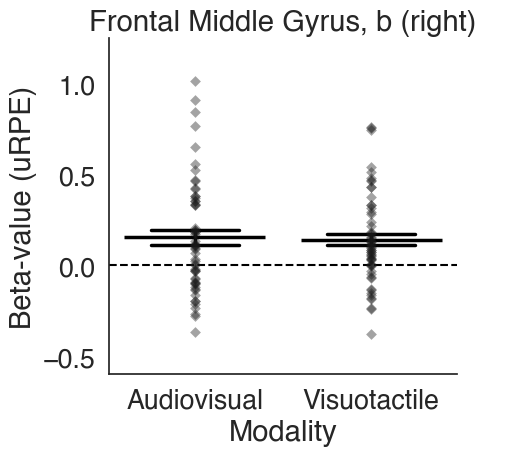

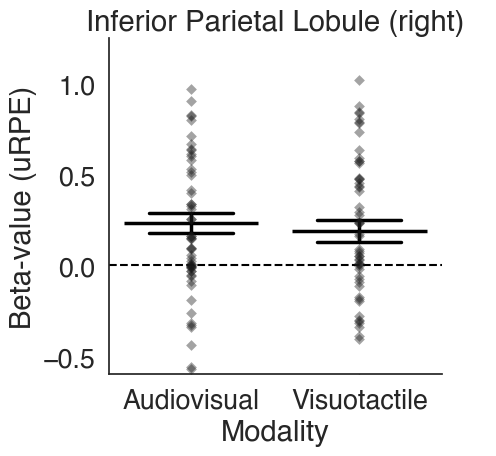

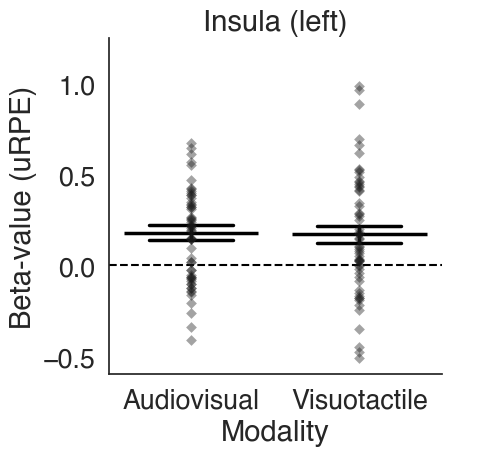

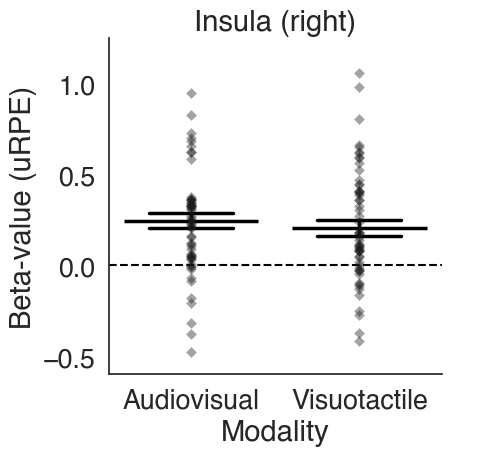

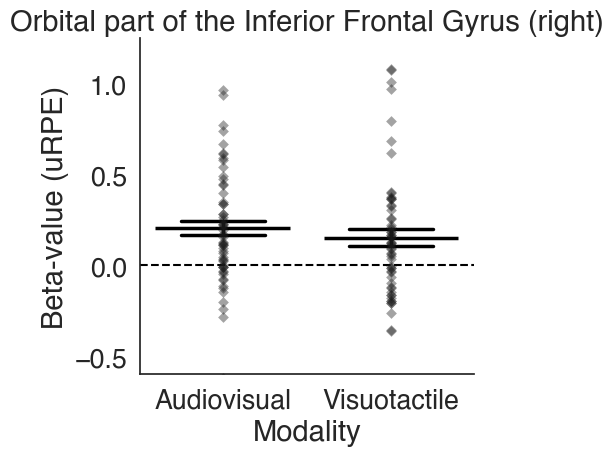

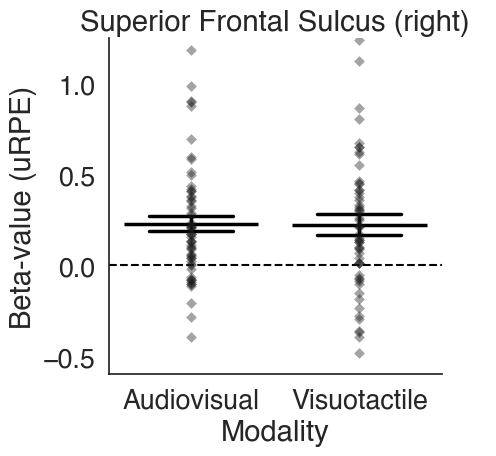

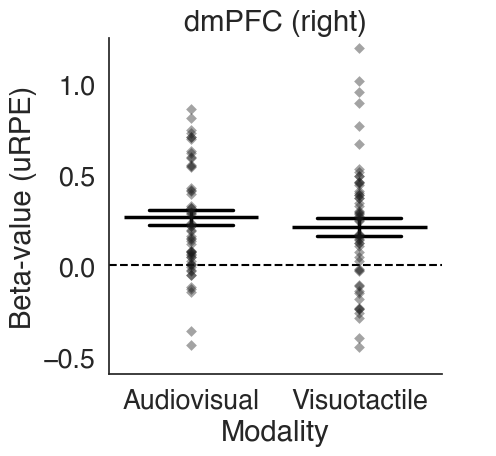

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_context('poster')
sns.set(font='helvetica', font_scale=1.75, style='white')

figure_dir = root_folder / 'figures'
figure_dir.mkdir(exist_ok=True, parents=True)

for cluster_label, b in betas_urpre.groupby('cluster_label'):
    g = sns.catplot(
        data=b,
        x='modality',
        y='beta',
        col='cluster_label',
        kind='strip',
        color='k',
        alpha=0.4,
        jitter=0.0,
        dodge=0.05,
        s=30,
        marker='D',  # Set marker to '+'

    )

    # Add a horizontal line at y=0
    g.map(plt.axhline, y=0, color='black', linestyle='--')

    # Overlay a point plot with SEM error bars, but hide the markers
    sns.pointplot(
        data=b,
        x='modality',
        y='beta',
        color='black',
        alpha=1.0,
        markersize=0,  # Hide the markers
        errorbar='se',
        linestyles='none',
        capsize=0.5,
        err_kws={'linewidth': 2.5},
        ax=g.axes[0, 0] if hasattr(g.axes, 'flatten') else g.ax
    )

    # Calculate means for each modality
    means = b.groupby('modality')['beta'].mean().values
    modalities = b['modality'].unique()

    # Overlay horizontal lines for the means
    ax = g.axes[0, 0] if hasattr(g.axes, 'flatten') else g.ax
    for i, mean in enumerate(means):
        ax.hlines(y=mean, xmin=i - 0.4, xmax=i + 0.4, colors='black', linewidth=2.5)

    g.set_axis_labels("Modality", "Beta-value (uRPE)")
    g.set_titles("{col_name}")
    g.set(ylim=(-0.6, 1.25))

    # Save the figure
    cluster_label_clean = str(cluster_label).replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
    g.savefig(figure_dir / f'urpe_betas_cluster_{cluster_label_clean}.pdf', dpi=300, bbox_inches='tight', transparent=True)
